# Flood-Driven Sediment Plumes in the Lower Fitzroy River–Estuary

## Project overview

This notebook investigates the spatial response of suspended-sediment plumes to flood and high-flow conditions in the lower Fitzroy River–estuary and Keppel Bay, Queensland, Australia, between 2017 and 2023.

The analysis integrates Landsat 8 and 9 Analysis Ready Data (ARD) from Digital Earth Australia (DEA) with Fitzroy River discharge observations to examine relative turbidity using the Normalised Difference Turbidity Index (NDTI2).

### Research question

**How did flood and high-flow events influence the spatial extent and relative turbidity of suspended-sediment plumes in the lower Fitzroy River–estuary between 2017 and 2023?**

### Analytical approach

The workflow:

1. loads and quality-controls Landsat 8 and 9 ARD;
2. restricts analysis to historically water-affected pixels using DEA Water Observations Statistics (WO-Stats);
3. calculates NDTI2 from red and green reflectance;
4. integrates daily Fitzroy River discharge observations;
5. classifies Landsat observations according to antecedent flow conditions;
6. establishes pixel-specific background NDTI2 conditions;
7. identifies and quantifies areas of elevated relative turbidity; and
8. compares the spatial response among selected high-flow events.

> **Interpretation:** NDTI2 is used here as an indicator of relative turbidity rather than as a direct estimate of total suspended solids (TSS).

### Tools

Python · Jupyter · Digital Earth Australia · xarray · pandas · NumPy · matplotlib · QGIS

## 1. Environment and imports

The analysis uses the Digital Earth Australia Sandbox and the Open Data Cube Python environment. The libraries below support data access, raster processing, numerical analysis, tabular data handling and visualisation.

### Load packages

In [1]:
%matplotlib inline


import datacube
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray
from IPython.display import Image
import geopandas
from geopandas import GeoDataFrame

from dea_tools.plotting import display_map, rgb, xr_animation
from dea_tools.spatial import xr_vectorize, xr_rasterize
from dea_tools.datahandling import load_ard, mostcommon_crs, wofs_fuser
from dea_tools.bandindices import calculate_indices

### Connect to the DEA datacube

In [2]:
dc = datacube.Datacube(app="Wetland_turbidity")

## 2. Study area and analysis period

The analysis focuses on the lower Fitzroy River–estuary and adjacent Keppel Bay, Queensland, Australia.

A geographic bounding box was defined around the lower estuary and used consistently for Landsat and water-occurrence data extraction. The analysis period spans **1 January 2017 to 31 December 2023**, capturing multiple flood and high-flow events.

In [3]:
# Fitzroy estuary study area
lat = -23.49
lon = 150.82

lat_buffer = 0.10
lon_buffer = 0.18

lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)

time_range = ("2017-01-01", "2023-12-31")

display_map(x=lon_range, y=lat_range)

## 3. Load and quality-control Landsat observations

Landsat 8 and 9 Collection 3 Analysis Ready Data were loaded from Digital Earth Australia for the study area and analysis period.

Red, green, blue and near-infrared reflectance were retrieved at 30 m resolution in GDA94 / Australian Albers (EPSG:3577). Observations were filtered using DEA's pixel-quality information, with Fmask masking applied to exclude invalid pixels. Scenes with less than 90% good-quality data across the study area were excluded.

In [4]:
query = {
    "x": lon_range,
    "y": lat_range,
    "time": time_range,
    "resolution": (-30, 30),
    "align": (15, 15),
}


# Define the coordinate system
output_crs = "EPSG:3577"

ds = load_ard(
    dc=dc,
    products=["ga_ls8c_ard_3", "ga_ls9c_ard_3"],
    measurements=["red", "green", "blue", "nir"],
    group_by="solar_day",
    dask_chunks={"time": 1, "x": 2000, "y": 2000},
    output_crs=output_crs,
    min_gooddata=0.9,
    **query
)

Finding datasets
    ga_ls8c_ard_3
    ga_ls9c_ard_3
Counting good quality pixels for each time step using fmask
Filtering to 76 out of 214 time steps with at least 90.0% good quality pixels
Applying fmask pixel quality/cloud mask
Returning 76 time steps as a dask array


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


In [5]:
# Display the dataset `ds`
ds

<xarray.Dataset> Size: 1GB
Dimensions:      (time: 76, y: 917, x: 1311)
Coordinates:
  * time         (time) datetime64[ns] 608B 2017-04-04T23:52:49.924655 ... 20...
  * y            (y) float64 7kB -2.66e+06 -2.66e+06 ... -2.687e+06 -2.687e+06
  * x            (x) float64 10kB 1.877e+06 1.877e+06 ... 1.916e+06 1.916e+06
    spatial_ref  int32 4B 3577
Data variables:
    red          (time, y, x) float32 365MB dask.array<chunksize=(1, 917, 1311), meta=np.ndarray>
    green        (time, y, x) float32 365MB dask.array<chunksize=(1, 917, 1311), meta=np.ndarray>
    blue         (time, y, x) float32 365MB dask.array<chunksize=(1, 917, 1311), meta=np.ndarray>
    nir          (time, y, x) float32 365MB dask.array<chunksize=(1, 917, 1311), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## 4. Define the water-occurrence mask

DEA Water Observations Statistics (WO-Stats) were used to restrict subsequent analysis to locations with a history of surface-water occurrence.

Pixels with **greater than 15% historical water occurrence** were retained. This reduces the inclusion of predominantly terrestrial pixels while allowing analysis across the estuary and adjacent shallow-water areas.

In [6]:
water = dc.load(
    product="ga_ls_wo_fq_myear_3",
    like=ds.geobox,
    dask_chunks={"time": 1, "x": 2000, "y": 2000},
)
# extract from mask the areas classified as water
water_extent = (water.frequency > 0.15).squeeze()

print(water_extent)

<xarray.DataArray 'frequency' (y: 917, x: 1311)> Size: 1MB
dask.array<getitem, shape=(917, 1311), dtype=bool, chunksize=(917, 1311), chunktype=numpy.ndarray>
Coordinates:
    time         datetime64[ns] 8B 2006-07-02T11:59:59.999999
  * y            (y) float64 7kB -2.66e+06 -2.66e+06 ... -2.687e+06 -2.687e+06
  * x            (x) float64 10kB 1.877e+06 1.877e+06 ... 1.916e+06 1.916e+06
    spatial_ref  int32 4B 3577


/tmp/ipykernel_3382/2454214443.py:3: DeprecationWarning: Geobox extraction logic has moved to odc-geo and the .geobox property is now deprecated. Please access via .odc.geobox instead.
  like=ds.geobox,


### Water-mask threshold

Pixels with historical water occurrence greater than **15%** were retained for subsequent NDTI2 analysis.

A relatively inclusive threshold was used because the lower Fitzroy is a dynamic, macrotidal estuarine environment in which the spatial distribution of water changes through time. The mask is therefore used to exclude predominantly terrestrial locations rather than to classify whether each pixel contained water at the exact time of every Landsat acquisition.

### Visual inspection of the water mask

The >15% WO-Stats water-occurrence mask was visually compared with satellite imagery to assess whether it captured the principal river, estuarine and coastal-water areas while excluding predominantly terrestrial pixels.

This inspection provides a qualitative quality-control check on the spatial mask used for subsequent NDTI2 analysis.

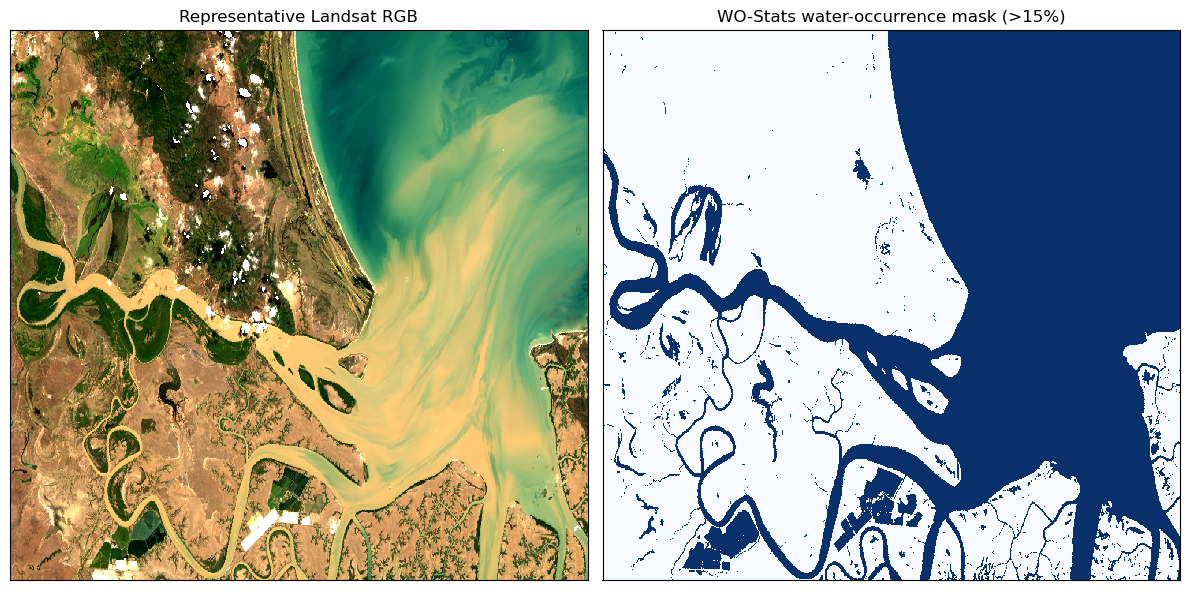

In [7]:
# Visual comparison of Landsat imagery and the WO-Stats water mask
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot a representative true-colour Landsat observation
rgb(
    ds.isel(time=5),
    bands=["red", "green", "blue"],
    ax=ax[0]
)

# Plot the >15% historical water-occurrence mask
water_extent.plot.imshow(
    ax=ax[1],
    cmap="Blues",
    add_colorbar=False
)

# Titles and formatting
ax[0].set_title("Representative Landsat RGB")
ax[1].set_title("WO-Stats water-occurrence mask (>15%)")

for axis in ax:
    axis.xaxis.set_visible(False)
    axis.yaxis.set_visible(False)

plt.tight_layout()
plt.show()

## 5. Calculate relative turbidity (NDTI2)

Relative turbidity was characterised using the **Normalised Difference Turbidity Index (NDTI2)** following Lacaux et al. (2007):

NDTI2 = Red - Green / Red + Green

NDTI2 exploits differences in red and green reflectance associated with suspended sediment and is used here as an indicator of **relative turbidity**, rather than as a direct estimate of total suspended solids (TSS).

The index was calculated for each Landsat observation and restricted to pixels within the >15% WO-Stats water-occurrence mask.

In [8]:
# Calculate Normalised Difference Turbidity Index (NDTI2)
ndti2 = (ds.red - ds.green) / (ds.red + ds.green)

# Restrict analysis to historically water-affected pixels
ndti2_water = ndti2.where(water_extent)

ndti2_water

<xarray.DataArray (time: 76, y: 917, x: 1311)> Size: 365MB
dask.array<where, shape=(76, 917, 1311), dtype=float32, chunksize=(1, 917, 1311), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 608B 2017-04-04T23:52:49.924655 ... 20...
  * y            (y) float64 7kB -2.66e+06 -2.66e+06 ... -2.687e+06 -2.687e+06
  * x            (x) float64 10kB 1.877e+06 1.877e+06 ... 1.916e+06 1.916e+06
    spatial_ref  int32 4B 3577

### Inspect the spatial NDTI2 response

Selected Landsat observations were visualised to examine spatial variation in NDTI2 across the water mask.

A consistent colour scale was applied across the example observations to support direct comparison of relative turbidity patterns before calculating observation-level summary statistics and integrating the satellite results with hydrological data.

In [9]:
ds = calculate_indices(ds.where(water_extent), index="NDTI2", collection="ga_ls_3")

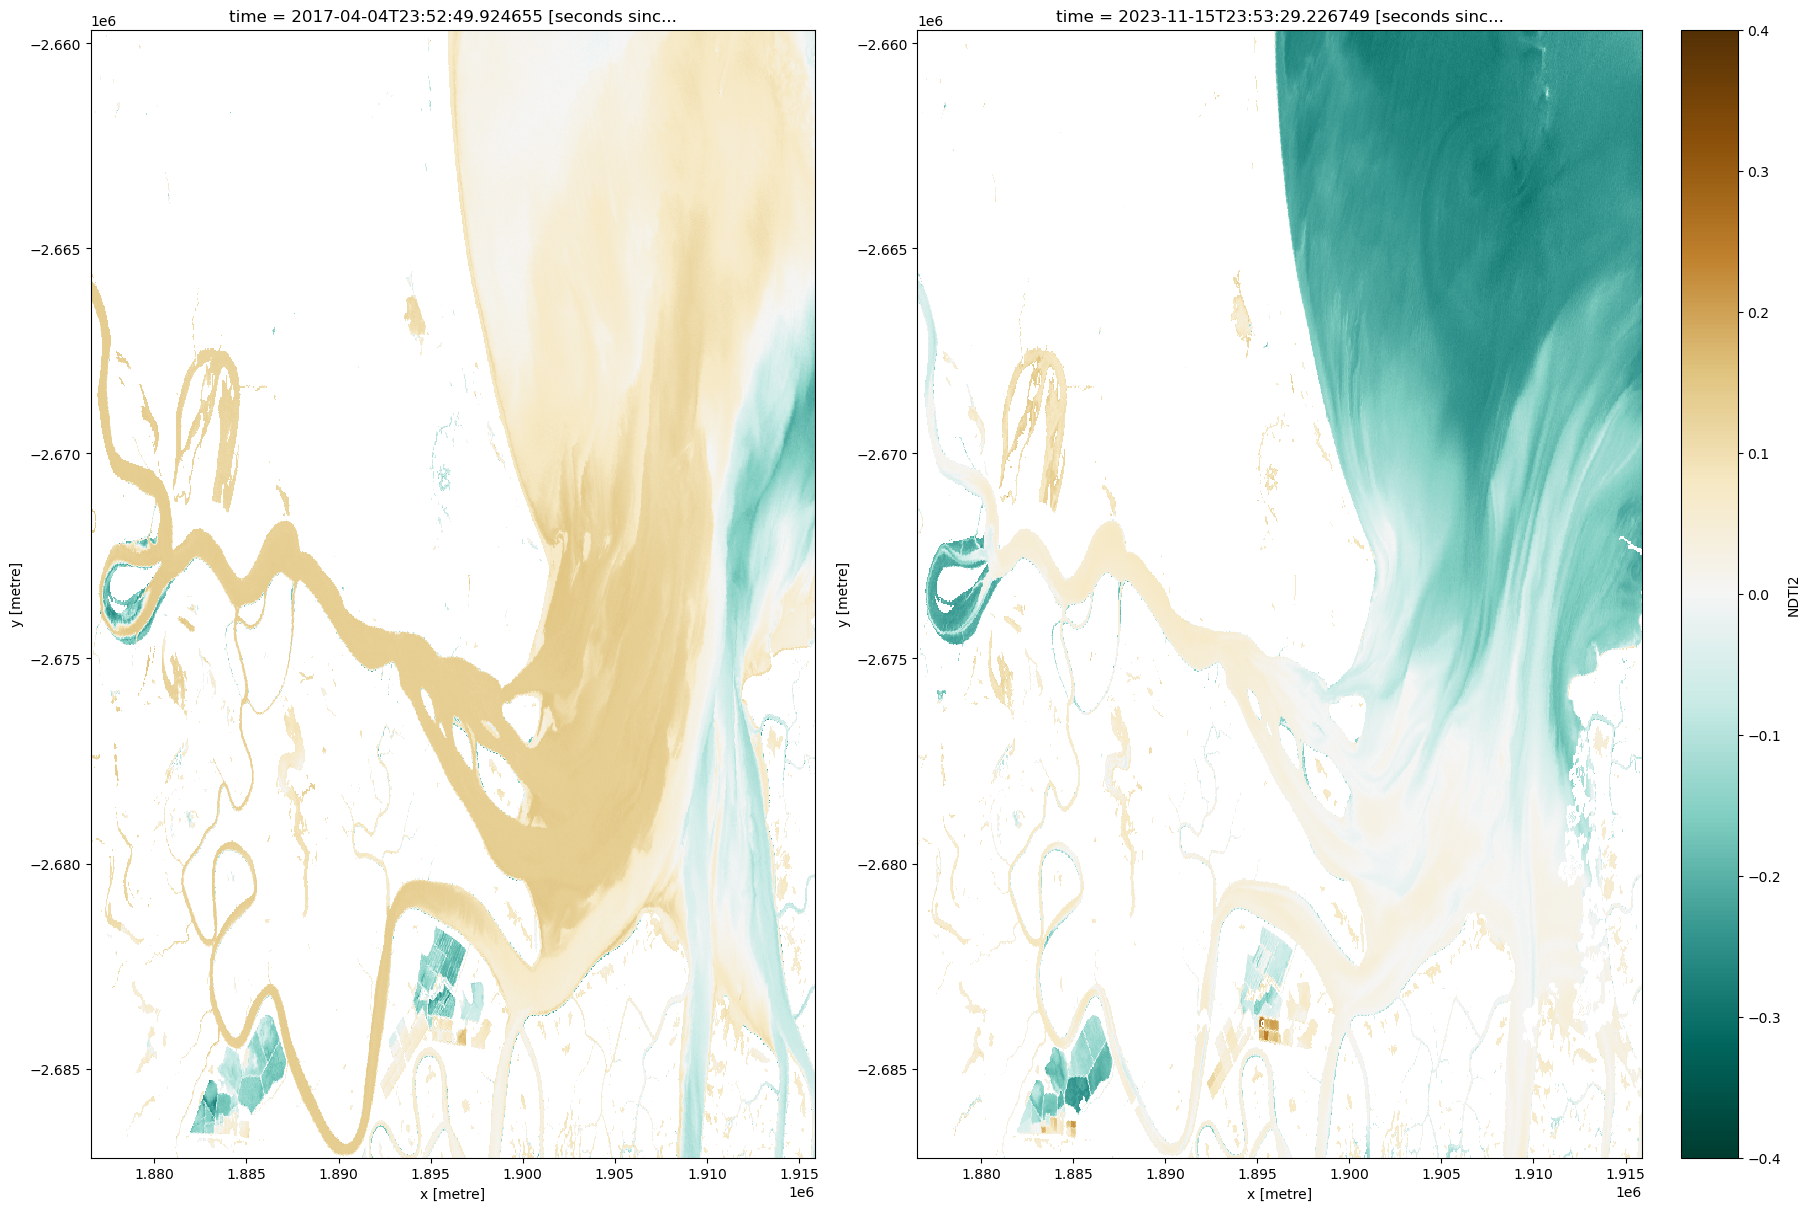

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(18, 12), constrained_layout=True)
cmap = "BrBG_r"
vmin = -0.4
vmax = 0.4

ds.NDTI2.isel(time=0).plot(
    ax=ax[0], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax
)
ds.NDTI2.isel(time=-1).plot(
    ax=ax[1], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax
)

### Observation-level NDTI2 statistics

For each usable Landsat observation, NDTI2 was summarised across the water-occurrence mask using two spatial statistics:

- **Median NDTI2** — represents the broader relative-turbidity response across the study area.
- **90th percentile (P90) NDTI2** — represents the relatively high-NDTI2 portion of the observation while reducing sensitivity to individual extreme pixels.

These complementary statistics were calculated for all 76 usable Landsat observations and subsequently compared with hydrological conditions.

In [11]:
import pandas as pd

In [12]:
# Summarise NDTI2 across water pixels for each Landsat observation

ndti2_df = pd.DataFrame({
    "time": pd.to_datetime(ds.time.values),

    "mean_NDTI2": ds.NDTI2.mean(
        dim=["x", "y"], skipna=True
    ).values,

    "median_NDTI2": ds.NDTI2.median(
        dim=["x", "y"], skipna=True
    ).values,

    "p90_NDTI2": ds.NDTI2.quantile(
        0.90, dim=["x", "y"], skipna=True
    ).values,

    "p10_NDTI2": ds.NDTI2.quantile(
        0.10, dim=["x", "y"], skipna=True
    ).values,

    "valid_water_pixels": ds.NDTI2.notnull().sum(
        dim=["x", "y"]
    ).values
})

ndti2_df.head()

,time,mean_NDTI2,median_NDTI2,p90_NDTI2,p10_NDTI2,valid_water_pixels
0,2017-04-04 23:52:49.924655,0.051737,0.063830,0.135904,-0.062465,552742
1,2017-05-06 23:52:36.758304,-0.055980,-0.015566,0.107587,-0.312233,552810
2,2017-06-07 23:52:56.580505,-0.166936,-0.129630,0.071009,-0.471939,552738
3,2017-06-23 23:53:02.169344,-0.155115,-0.118092,0.067789,-0.438499,552590
4,2017-07-25 23:53:12.202911,-0.049273,0.013864,0.101014,-0.285930,552455


In [13]:
# Confirm the temporal coverage of the analysis dataset
print(f"Usable Landsat observations: {len(ndti2_df)}")
print(
    f"Observation period: "
    f"{ndti2_df['time'].min():%d %b %Y} to "
    f"{ndti2_df['time'].max():%d %b %Y}"
)

Usable Landsat observations: 76
Observation period: 04 Apr 2017 to 15 Nov 2023


### Analysis dataset check

Following quality filtering and water masking, **76 Landsat observations** were retained for NDTI2 analysis across 2017–2023.

In [14]:
# Confirm the size and temporal coverage of the analysis dataset

print("Usable Landsat observations:", len(ndti2_df))
print("First observation:", ndti2_df["time"].min())
print("Last observation:", ndti2_df["time"].max())

Usable Landsat observations: 76
First observation: 2017-04-04 23:52:49.924655
Last observation: 2023-11-15 23:53:29.226749


## 6. Integrate Fitzroy River discharge

Daily river-discharge observations were incorporated to investigate whether Landsat-derived relative turbidity varied with recent hydrological conditions.

Discharge data were obtained from the Queensland Water Monitoring Information Portal (WMIP), station **130005A — Fitzroy River at The Gap**, and expressed in megalitres per day (ML/day).

For each Landsat acquisition, antecedent hydrological conditions were characterised using:

- 3-day mean discharge;
- 7-day mean discharge; and
- 7-day maximum discharge.

The **7-day maximum discharge** was subsequently used to classify Landsat observations according to recent flow conditions preceding each acquisition.

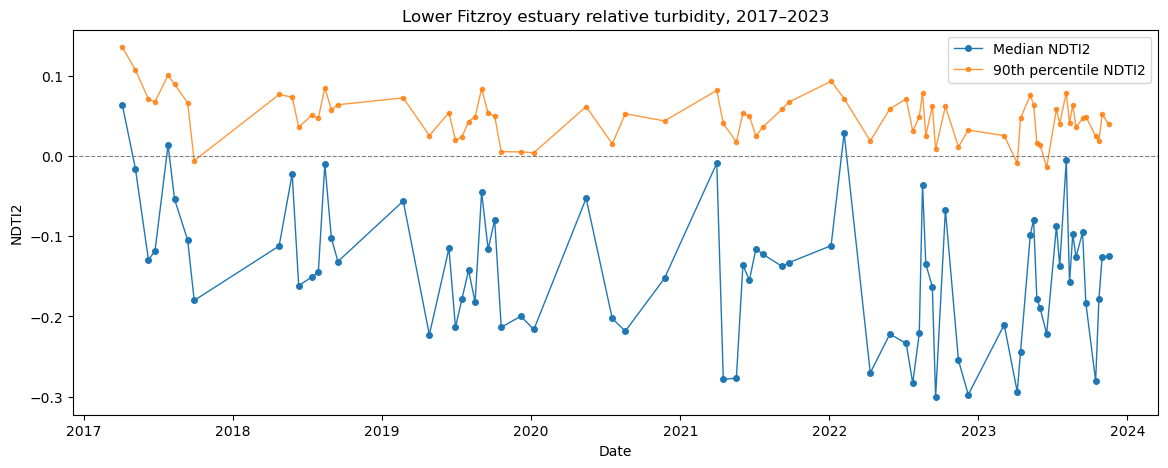

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    ndti2_df["time"],
    ndti2_df["median_NDTI2"],
    marker="o",
    markersize=4,
    linewidth=1,
    label="Median NDTI2"
)

ax.plot(
    ndti2_df["time"],
    ndti2_df["p90_NDTI2"],
    marker="o",
    markersize=3,
    linewidth=1,
    alpha=0.8,
    label="90th percentile NDTI2"
)

ax.axhline(
    0,
    color="grey",
    linestyle="--",
    linewidth=0.8
)

ax.set_ylabel("NDTI2")
ax.set_xlabel("Date")
ax.set_title("Lower Fitzroy estuary relative turbidity, 2017–2023")
ax.legend()

plt.show()

Finally, save the analysis table

In [16]:
ndti2_df.to_csv(
    "Fitzroy_NDTI2_summary_2017_2023.csv",
    index=False
)

### Load and clean discharge observations

Daily discharge observations from Queensland's Water Monitoring Information Portal (WMIP), station **130005A — Fitzroy River at The Gap**, were imported and cleaned before calculating antecedent-flow metrics.

The source dataset contains additional hydrological variables; only the date and daily discharge fields required for this analysis were retained.

In [17]:
# Load daily Fitzroy River discharge observations
flow_file = "130005A.csv"

flow_raw = pd.read_csv(
    flow_file,
    skiprows=4
)

print(f"Raw records: {len(flow_raw):,}")
flow_raw.head()

Raw records: 22,757


,30/04/1964 0:00,Unnamed: 1,255,Unnamed: 3,255.1,Unnamed: 5,255.2,Sites:
0,1/05/1964 0:00,382.266,9,368.107,9,396.662,9,130005A - Fitzroy River at The Gap Lat:-23.088...
1,2/05/1964 0:00,357.854,9,354.456,9,368.107,9,
2,3/05/1964 0:00,351.115,9,341.150,9,354.456,9,Variables:
3,4/05/1964 0:00,331.492,9,328.277,9,341.150,9,140 - Stream Discharge (Cumecs)
4,5/05/1964 0:00,325.156,9,315.835,9,328.277,9,141 - Stream Discharge (Megalitres/Day)


In [18]:
import pandas as pd

flow_file = "130005A.csv"

flow_raw = pd.read_csv(flow_file)

print("Shape:", flow_raw.shape)
print("\nColumns:")
print(flow_raw.columns.tolist())

flow_raw.head(15)

Shape: (22761, 8)

Columns:
['Time', '130005A', 'Unnamed: 2', '130005A.1', 'Unnamed: 4', '130005A.2', 'Unnamed: 6', 'Unnamed: 7']


,Time,130005A,Unnamed: 2,130005A.1,Unnamed: 4,130005A.2,Unnamed: 6,Unnamed: 7
0,and,141,NaN,141,NaN,141,NaN,NaN
1,Date,Discharge (ML/day),NaN,Discharge (ML/day),NaN,Discharge (ML/day),NaN,NaN
2,Date and time,Mean,Quality,Min,Quality,Max,Quality,Comments
3,30/04/1964 0:00,NaN,255,NaN,255,NaN,255,Sites:
4,1/05/1964 0:00,382.266,9,368.107,9,396.662,9,130005A - Fitzroy River at The Gap Lat:-23.088...
5,2/05/1964 0:00,357.854,9,354.456,9,368.107,9,
6,3/05/1964 0:00,351.115,9,341.15,9,354.456,9,Variables:
7,4/05/1964 0:00,331.492,9,328.277,9,341.15,9,140 - Stream Discharge (Cumecs)
8,5/05/1964 0:00,325.156,9,315.835,9,328.277,9,141 - Stream Discharge (Megalitres/Day)
9,6/05/1964 0:00,306.785,9,303.782,9,315.835,9,


### Clean the discharge dataset

The WMIP discharge data were reduced to the fields required for analysis. Dates were parsed to a consistent datetime format, discharge values were converted to numeric form, invalid observations were removed, and records were sorted chronologically.

The cleaned daily discharge series was then used to calculate antecedent-flow conditions associated with each Landsat acquisition.

In [19]:
# Extract the fields required for the analysis
flow = flow_raw[["Time", "130005A", "Unnamed: 2"]].copy()

flow.columns = [
    "date",
    "discharge_ML_day",
    "quality_code"
]

# Convert fields to appropriate data types
flow["date"] = pd.to_datetime(
    flow["date"],
    dayfirst=True,
    errors="coerce"
)

flow["discharge_ML_day"] = pd.to_numeric(
    flow["discharge_ML_day"],
    errors="coerce"
)

flow["quality_code"] = pd.to_numeric(
    flow["quality_code"],
    errors="coerce"
)

# Remove metadata/non-data rows
flow = flow.dropna(
    subset=["date", "discharge_ML_day"]
)

# Restrict to study period
flow = flow[
    (flow["date"] >= "2017-01-01") &
    (flow["date"] <= "2023-12-31")
].copy()

flow = flow.sort_values("date").reset_index(drop=True)

flow.head()

,date,discharge_ML_day,quality_code
0,2017-01-01,1011.550,10.0
1,2017-01-02,860.927,10.0
2,2017-01-03,763.178,10.0
3,2017-01-04,685.921,10.0
4,2017-01-05,616.183,10.0


In [20]:
print("Number of daily records:", len(flow))
print("Start:", flow["date"].min())
print("End:", flow["date"].max())

print("\nQuality codes:")
print(flow["quality_code"].value_counts().sort_index())

flow["discharge_ML_day"].describe()

Number of daily records: 2556
Start: 2017-01-01 00:00:00
End: 2023-12-31 00:00:00

Quality codes:
quality_code
10.0    1966
15.0     585
20.0       5
Name: count, dtype: int64


count      2556.000000
mean       7153.632397
std       38116.645056
min           0.000000
25%           0.908250
50%         210.195000
75%        1878.841500
max      824968.373000
Name: discharge_ML_day, dtype: float64

Discharge quality control: WMIP discharge records for 2017–2023 contained quality codes 10 (Good), 15 (water level below threshold/no flow), and 20 (Fair). All were retained because no-flow observations represent hydrologically meaningful conditions rather than missing data. Quality codes were retained alongside discharge values to identify any analyses dependent on lower-quality observations.


### Calculate antecedent-flow metrics

Recent discharge conditions were characterised using rolling hydrological metrics calculated from the cleaned daily discharge series:

- **3-day mean discharge**
- **7-day mean discharge**
- **7-day maximum discharge**

These metrics provide alternative summaries of recent flow conditions preceding each Landsat acquisition. The 7-day maximum was used later for flow classification because it captures short-lived high-flow peaks that may not be represented by discharge on the acquisition date alone.

In [21]:
# Calculate antecedent discharge metrics

flow["mean_3d"] = (
    flow["discharge_ML_day"]
    .rolling(window=3, min_periods=1)
    .mean()
)

flow["mean_7d"] = (
    flow["discharge_ML_day"]
    .rolling(window=7, min_periods=1)
    .mean()
)

flow["max_7d"] = (
    flow["discharge_ML_day"]
    .rolling(window=7, min_periods=1)
    .max()
)

### Match hydrological conditions to Landsat observations

Landsat acquisition timestamps and discharge observations were normalised to calendar dates so that each usable satellite observation could be matched with same-date discharge and the corresponding antecedent-flow metrics.

In [22]:
# Create matching calendar dates

flow["date_only"] = flow["date"].dt.normalize()

ndti2_df["landsat_date"] = (
    pd.to_datetime(ndti2_df["time"])
    .dt.normalize()
)

### Combine satellite and hydrological metrics

In [23]:
analysis_df = ndti2_df.merge(
    flow[
        [
            "date_only",
            "discharge_ML_day",
            "mean_3d",
            "mean_7d",
            "max_7d",
            "quality_code"
        ]
    ],
    left_on="landsat_date",
    right_on="date_only",
    how="left"
)

analysis_df[
    [
        "landsat_date",
        "median_NDTI2",
        "p90_NDTI2",
        "discharge_ML_day",
        "mean_3d",
        "mean_7d",
        "max_7d"
    ]
].head(10)

,landsat_date,median_NDTI2,p90_NDTI2,discharge_ML_day,mean_3d,mean_7d,max_7d
0,2017-04-04,0.063830,0.135904,698297.149,504466.887667,321651.721857,698297.149
1,2017-05-06,-0.015566,0.107587,1360.773,1430.747000,1605.521714,1900.615
2,2017-06-07,-0.129630,0.071009,1524.753,1700.517000,2111.016143,2893.289
3,2017-06-23,-0.118092,0.067789,677.766,701.076667,760.227143,852.970
4,2017-07-25,0.013864,0.101014,250.560,257.796333,279.252857,312.937
5,2017-08-10,-0.053967,0.089612,170.807,176.126333,184.237286,195.999
6,2017-09-11,-0.104715,0.066541,72.344,77.014667,82.987286,91.368
7,2017-09-27,-0.180066,-0.005632,18.044,19.801333,23.959429,30.434
8,2018-04-23,-0.112069,0.076923,858.080,954.914000,1258.489143,1863.585
9,2018-05-25,-0.022264,0.073557,118.265,125.231000,138.286429,154.904


## 7. Classify hydrological conditions

Flow conditions were classified using the distribution of daily Fitzroy River discharge during the 2017–2023 study period.

Three percentile thresholds were calculated:

- **P90** — high-flow threshold
- **P95** — very-high-flow threshold
- **P99** — extreme-flow threshold

For each Landsat observation, classification was based on the **maximum discharge during the preceding seven-day window (`max_7d`)**. This approach captures short-lived flow peaks that could precede the satellite acquisition rather than relying only on same-day discharge.

In [24]:
# Calculate discharge percentile thresholds for 2017–2023

study_flow = flow[
    flow["date"].between("2017-01-01", "2023-12-31")
].copy()

p90 = study_flow["discharge_ML_day"].quantile(0.90)
p95 = study_flow["discharge_ML_day"].quantile(0.95)
p99 = study_flow["discharge_ML_day"].quantile(0.99)

print(f"P90 high-flow threshold:      {p90:,.0f} ML/day")
print(f"P95 very-high-flow threshold: {p95:,.0f} ML/day")
print(f"P99 extreme-flow threshold:   {p99:,.0f} ML/day")

P90 high-flow threshold:      10,564 ML/day
P95 very-high-flow threshold: 33,236 ML/day
P99 extreme-flow threshold:   113,099 ML/day


### Classify Landsat observations by antecedent flow

Each Landsat observation was assigned a hydrological class using its **7-day maximum discharge (`max_7d`)** and the percentile thresholds calculated from the 2017–2023 discharge record.

Classification rules were:

- **Background flow:** < P90
- **High flow:** ≥ P90 and < P95
- **Very high flow:** ≥ P95 and < P99
- **Extreme flow:** ≥ P99


In [25]:
# Classify Landsat observations using antecedent 7-day maximum discharge

def classify_flow(q):
    if q >= p99:
        return "Extreme flow"
    elif q >= p95:
        return "Very high flow"
    elif q >= p90:
        return "High flow"
    else:
        return "Background flow"

analysis_df["flow_class"] = analysis_df["max_7d"].apply(classify_flow)

analysis_df["flow_class"].value_counts()

flow_class
Background flow    68
High flow           5
Very high flow      2
Extreme flow        1
Name: count, dtype: int64

In [26]:
highflow_scenes = (
    analysis_df[
        analysis_df["flow_class"] != "Background flow"
    ][
        [
            "landsat_date",
            "flow_class",
            "max_7d",
            "median_NDTI2",
            "p90_NDTI2"
        ]
    ]
    .sort_values("landsat_date")
    .reset_index(drop=True)
)

highflow_scenes

,landsat_date,flow_class,max_7d,median_NDTI2,p90_NDTI2
0,2017-04-04,Extreme flow,698297.149,0.063830,0.135904
1,2019-02-21,Very high flow,43649.348,-0.056009,0.072692
2,2021-03-30,High flow,22250.130,-0.008776,0.081996
3,2022-01-04,High flow,12674.161,-0.111732,0.093387
4,2022-05-28,High flow,29551.185,-0.221941,0.059046
5,2022-09-17,High flow,14033.666,-0.300787,0.008969
6,2022-11-12,High flow,22673.755,-0.254826,0.011597
7,2022-12-06,Very high flow,85617.710,-0.297571,0.032581


Classify the satellite observations - Use the 7-day maximum discharge initially:

In [28]:
# Classify Landsat observations using antecedent 7-day maximum discharge

def classify_flow(q):
    if q >= p99:
        return "Extreme flow"
    elif q >= p95:
        return "Very high flow"
    elif q >= p90:
        return "High flow"
    else:
        return "Background flow"


analysis_df["flow_class"] = (
    analysis_df["max_7d"]
    .apply(classify_flow)
)

analysis_df["flow_class"].value_counts()

flow_class
Background flow    68
High flow           5
Very high flow      2
Extreme flow        1
Name: count, dtype: int64

We will then be able to compare, for example:

background flow vs high/extreme flow
→ p90 NDTI2
→ median NDTI2
→ eventually area of elevated relative turbidity

and select specific high-flow Landsat scenes for plume maps.

RESULTS = 76 usable observations divide into 68 background, 5 high-flow, 2 very-high-flow, and 1 extreme-flow observation. Next: identify those eight high flow observations

In [29]:
highflow_scenes = (
    analysis_df[
        analysis_df["flow_class"] != "Background flow"
    ][
        [
            "landsat_date",
            "flow_class",
            "discharge_ML_day",
            "mean_3d",
            "mean_7d",
            "max_7d",
            "median_NDTI2",
            "p90_NDTI2",
            "valid_water_pixels"
        ]
    ]
    .sort_values("landsat_date")
    .reset_index(drop=True)
)

highflow_scenes

,landsat_date,flow_class,discharge_ML_day,mean_3d,mean_7d,max_7d,median_NDTI2,p90_NDTI2,valid_water_pixels
0,2017-04-04,Extreme flow,698297.149,504466.887667,321651.721857,698297.149,0.063830,0.135904,552742
1,2019-02-21,Very high flow,4161.987,5115.280333,13695.017429,43649.348,-0.056009,0.072692,547669
2,2021-03-30,High flow,17749.773,9689.556000,12606.662571,22250.130,-0.008776,0.081996,521571
3,2022-01-04,High flow,9786.287,11488.996333,7299.821571,12674.161,-0.111732,0.093387,551862
4,2022-05-28,High flow,13142.323,14192.331000,20964.434286,29551.185,-0.221941,0.059046,552760
5,2022-09-17,High flow,4907.809,7050.279000,6709.873714,14033.666,-0.300787,0.008969,521898
6,2022-11-12,High flow,16570.440,20282.498333,18962.012000,22673.755,-0.254826,0.011597,536866
7,2022-12-06,Very high flow,85617.710,57717.387000,26640.985000,85617.710,-0.297571,0.032581,552812


It shows that high flow does not produce a uniform NDTI2 response, which means the spatial analysis is essential.

A few patterns already stand out. The 4 Apr 2017 extreme-flow scene has the highest p90 NDTI2 in the table (approx 0.136), and the 21 Feb 2019 very-high-flow scene also has elevated p90 (approx 0.073). But several 2022 high-flow scenes have strongly negative median NDTI2 and only modest p90 values. So we should not conclude “higher discharge = higher whole-estuary NDTI2”. A plume may occupy only part of the AOI, move offshore, or be affected by timing, tides and resuspension.

The most useful event set is now:

4 Apr 2017 — Extreme flow

21 Feb 2019 — Very high flow

30 Mar 2021 — High flow

4 Jan 2022 — High flow

12 Nov 2022 — High flow — especially useful because this overlaps the AquaWatch/CSIRO field campaign

6 Dec 2022 — Very high flow


## 8. Establish background turbidity conditions

## Define elevated turbidity relative to background

68 background-flow Landsat scenes
→ calculate the 90th percentile NDTI2 at each water pixel
→ for each high-flow scene, flag pixels whose NDTI2 exceeds that pixel’s normal 90th-percentile value
→ calculate the area of those elevated pixels. This shows area of unusually high relative turbidity compared with local background conditions

# Identify background Landsat dates

In [30]:
background_dates = (
    analysis_df.loc[
        analysis_df["flow_class"] == "Background flow",
        "landsat_date"
    ]
    .dt.normalize()
    .unique()
)

len(background_dates)

68

Build a mask identifying background scenes in

In [31]:
ds_dates = pd.to_datetime(ds.time.values).normalize()

background_mask = np.isin(
    ds_dates,
    background_dates
)

print("Background scenes in xarray:", background_mask.sum())

Background scenes in xarray: 68


### Derive pixel-specific background thresholds

Background turbidity was characterised using the 68 Landsat observations classified as background-flow conditions.

Rather than applying a single NDTI2 threshold across the study area, the 90th percentile of background NDTI2 was calculated independently for each water pixel. This accounts for persistent spatial differences in baseline reflectance and turbidity across the estuary.

For subsequent high-flow observations, a pixel was classified as having **elevated NDTI2** where its NDTI2 value exceeded that pixel's background 90th-percentile threshold.

Calculate the local background NDTI2

In [32]:
background_ndti2 = ds.NDTI2.isel(
    time=np.where(background_mask)[0]
)

background_median = background_ndti2.median(
    dim="time",
    skipna=True
)

background_q90 = background_ndti2.quantile(
    0.90,
    dim="time",
    skipna=True
)

background_median

<xarray.DataArray 'NDTI2' (y: 917, x: 1311)> Size: 5MB
dask.array<nanmedian, shape=(917, 1311), dtype=float32, chunksize=(587, 839), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 7kB -2.66e+06 -2.66e+06 ... -2.687e+06 -2.687e+06
  * x            (x) float64 10kB 1.877e+06 1.877e+06 ... 1.916e+06 1.916e+06
    spatial_ref  int32 4B 3577

## 9. Visualise hydrological context and Landsat observations

Daily Fitzroy River discharge was plotted alongside the usable Landsat observations to show the hydrological conditions represented by the satellite record. Discharge percentile thresholds used for flow classification (P90, P95 and P99) provide context for identifying high-flow observations selected for subsequent spatial analysis.

### Discharge and Landsat observation timeline

In [33]:
# Check event classifications used in Figure 3

figure3_events = (
    analysis_df.loc[
        analysis_df["flow_class"] != "Background flow",
        ["landsat_date", "max_7d", "flow_class"]
    ]
    .sort_values("landsat_date")
    .reset_index(drop=True)
)

print(f"P90 threshold: {p90:,.0f} ML/day")
print(f"P95 threshold: {p95:,.0f} ML/day")
print(f"P99 threshold: {p99:,.0f} ML/day")
print(f"Non-background Landsat observations: {len(figure3_events)}")

figure3_events

P90 threshold: 10,564 ML/day
P95 threshold: 33,236 ML/day
P99 threshold: 113,099 ML/day
Non-background Landsat observations: 8


,landsat_date,max_7d,flow_class
0,2017-04-04,698297.149,Extreme flow
1,2019-02-21,43649.348,Very high flow
2,2021-03-30,22250.130,High flow
3,2022-01-04,12674.161,High flow
4,2022-05-28,29551.185,High flow
5,2022-09-17,14033.666,High flow
6,2022-11-12,22673.755,High flow
7,2022-12-06,85617.710,Very high flow


### Figure 3 Plotting Code

In [34]:
# Figure 3: plotting setup

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plot_flow = flow.copy()

figure3_events = (
    analysis_df.loc[
        analysis_df["flow_class"] != "Background flow",
        ["landsat_date", "max_7d", "flow_class"]
    ]
    .sort_values("landsat_date")
    .reset_index(drop=True)
)

In [35]:
# Colours used for flow classes

flow_colours = {
    "High flow": "#E6A700",
    "Very high flow": "#F28E2B",
    "Extreme flow": "#C62828"
}

(np.float64(17167.0), np.float64(19722.0))

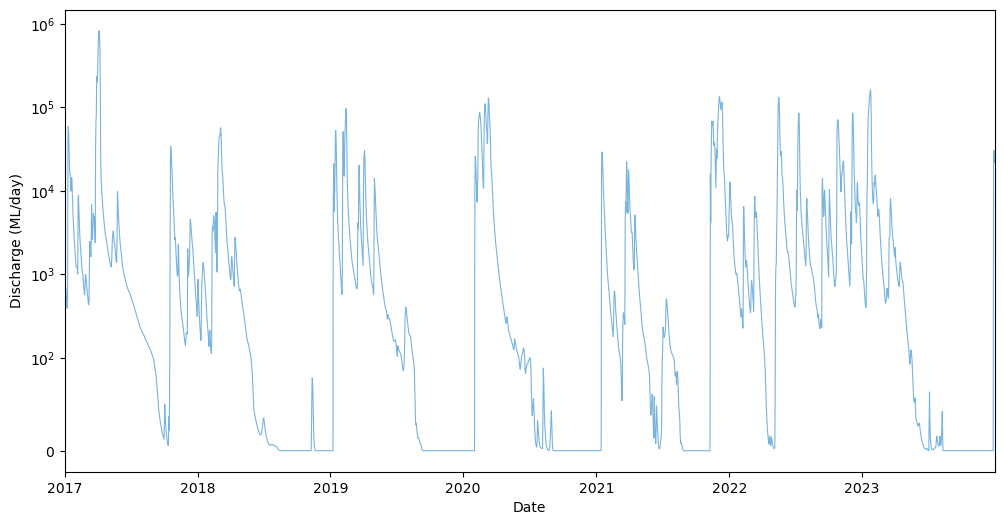

In [36]:
# Plot daily Fitzroy River discharge

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    plot_flow["date"],
    plot_flow["discharge_ML_day"],
    color="#4C9BD3",
    linewidth=0.8,
    alpha=0.75,
    label="Daily mean discharge"
)

ax.set_ylabel("Discharge (ML/day)")
ax.set_xlabel("Date")

# Symmetric log scale retains very low/zero flows
# while accommodating extreme flood discharge.
ax.set_yscale("symlog", linthresh=100)

ax.set_xlim(
    pd.Timestamp("2017-01-01"),
    pd.Timestamp("2023-12-31")
)

In [37]:
# Add discharge thresholds used for flow classification

ax.axhline(
    p90,
    color="#E6A700",
    linestyle="--",
    linewidth=1.0,
    label=f"P90 = {p90:,.0f} ML/day"
)

ax.axhline(
    p95,
    color="#F28E2B",
    linestyle="--",
    linewidth=1.0,
    label=f"P95 = {p95:,.0f} ML/day"
)

ax.axhline(
    p99,
    color="#C62828",
    linestyle="--",
    linewidth=1.0,
    label=f"P99 = {p99:,.0f} ML/day"
)

In [38]:
# Mark all usable Landsat observations

for date in analysis_df["landsat_date"]:
    ax.axvline(
        date,
        color="grey",
        linewidth=0.45,
        alpha=0.20,
        zorder=1
    )

In [39]:
# Highlight high-flow Landsat observations

for flow_class, colour in flow_colours.items():

    subset = figure3_events[
        figure3_events["flow_class"] == flow_class
    ]

    ax.scatter(
        subset["landsat_date"],
        subset["max_7d"],
        s=40,
        color=colour,
        edgecolor="black",
        linewidth=0.5,
        zorder=5,
        label=f"Landsat: {flow_class}"
    )

In [40]:
# Format time axis and grid

ax.xaxis.set_major_locator(mdates.YearLocator())

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.xaxis.set_minor_locator(
    mdates.MonthLocator(interval=3)
)

ax.grid(
    axis="x",
    which="minor",
    linestyle=":",
    linewidth=0.4,
    alpha=0.20
)

ax.grid(
    axis="y",
    which="major",
    linestyle=":",
    linewidth=0.5,
    alpha=0.25
)

In [41]:
# Final title and legend

ax.set_title(
    "Fitzroy River discharge and usable Landsat observations, 2017–2023"
)

ax.legend(
    loc="upper right",
    fontsize=7,
    frameon=True
)

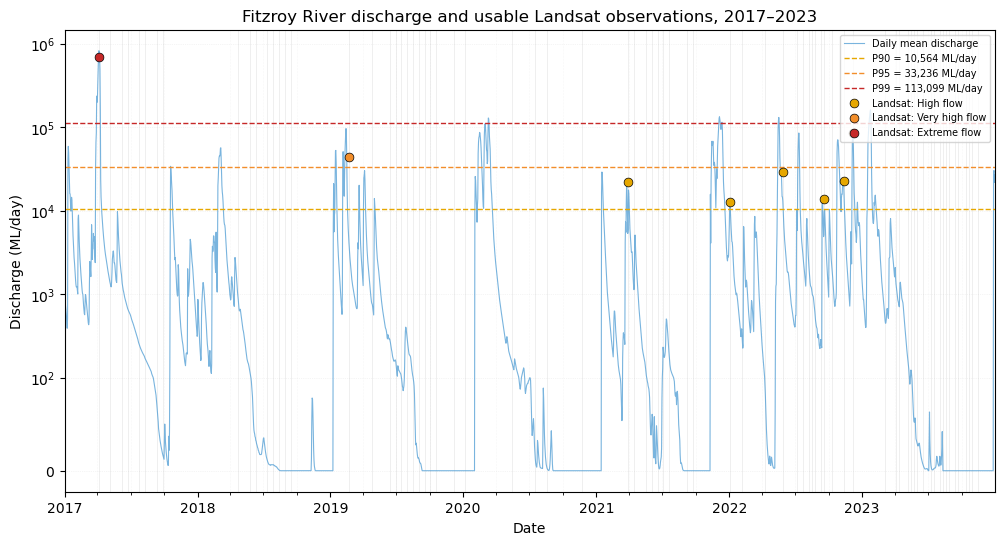

<Figure size 640x480 with 0 Axes>

In [42]:
# Finalise layout

plt.subplots_adjust(right=0.76)

fig

## 10. Quantify elevated NDTI2 during high-flow events

For each non-background Landsat observation, NDTI2 was compared with the pixel-specific background P90 threshold.

Pixels exceeding their local background P90 were classified as **elevated NDTI2**. The number of elevated pixels was converted to area using the 30 × 30 m Landsat pixel size.

In [44]:
# Confirm Landsat pixel dimensions and area

pixel_width = float(abs(ds.x[1] - ds.x[0]))
pixel_height = float(abs(ds.y[1] - ds.y[0]))

pixel_area_km2 = (
    pixel_width * pixel_height
) / 1_000_000

print(f"Pixel width:  {pixel_width:.1f} m")
print(f"Pixel height: {pixel_height:.1f} m")
print(f"Pixel area:   {pixel_area_km2:.4f} km²")

Pixel width:  30.0 m
Pixel height: 30.0 m
Pixel area:   0.0009 km²


In [45]:
# Prepare high-flow event analysis

event_results = []

ds_dates = pd.to_datetime(
    ds.time.values
).normalize()

print(
    f"High-flow observations to analyse: "
    f"{len(highflow_scenes)}"
)

High-flow observations to analyse: 8


Each 30 m Landsat pixel represents:30m×30m=900m (sq)=0.0009km (sq)

In [46]:
pixel_area_km2 = 0.0009

event_results = []

for _, row in highflow_scenes.iterrows():

    event_date = pd.Timestamp(
        row["landsat_date"]
    ).normalize()

    # Locate Landsat scene matching this date
    idx = np.where(ds_dates == event_date)[0]

    if len(idx) == 0:
        continue

    event = ds.NDTI2.isel(time=idx[0])

    # Identify pixels above their local background
    # 90th-percentile NDTI2
    elevated = event > background_q90

    # Count elevated pixels
    elevated_pixels = int(
        elevated.sum().compute().values
    )

    elevated_area_km2 = (
        elevated_pixels * pixel_area_km2
    )

    # Difference from each pixel's normal background value
    anomaly = event - background_median

    # Compute the 2-D scene before taking median
    anomaly_values = anomaly.compute()

    median_anomaly = float(
        anomaly_values.median(
            dim=["x", "y"],
            skipna=True
        ).values
    )

    event_results.append({
        "date": event_date,
        "flow_class": row["flow_class"],
        "max_7d_ML_day": row["max_7d"],
        "median_NDTI2": row["median_NDTI2"],
        "p90_NDTI2": row["p90_NDTI2"],
        "elevated_area_km2": elevated_area_km2,
        "median_NDTI2_anomaly": median_anomaly
    })

event_df = pd.DataFrame(event_results)

event_df

,date,flow_class,max_7d_ML_day,median_NDTI2,p90_NDTI2,elevated_area_km2,median_NDTI2_anomaly
0,2017-04-04,Extreme flow,698297.149,0.063830,0.135904,397.1313,0.191442
1,2019-02-21,Very high flow,43649.348,-0.056009,0.072692,142.9065,0.092222
2,2021-03-30,High flow,22250.130,-0.008776,0.081996,247.7907,0.109546
3,2022-01-04,High flow,12674.161,-0.111732,0.093387,119.9772,0.050578
4,2022-05-28,High flow,29551.185,-0.221941,0.059046,38.2698,-0.041743
5,2022-09-17,High flow,14033.666,-0.300787,0.008969,13.4685,-0.130886
6,2022-11-12,High flow,22673.755,-0.254826,0.011597,13.1634,-0.047632
7,2022-12-06,Very high flow,85617.710,-0.297571,0.032581,24.7365,-0.083888


In [47]:
# Compare each high-flow Landsat observation with local background conditions

for _, row in highflow_scenes.iterrows():

    # Normalise event date to calendar date
    event_date = pd.Timestamp(
        row["landsat_date"]
    ).normalize()

    # Find the corresponding Landsat observation
    idx = np.where(
        ds_dates == event_date
    )[0]

    # Temporary QC check
    print(event_date.date(), "matches:", len(idx))

    # Skip only if no matching Landsat observation exists
    if len(idx) == 0:
        continue

    # Extract NDTI2 for the matching Landsat observation
    event = ds.NDTI2.isel(
        time=idx[0]
    )

    # Identify pixels where event NDTI2 exceeds
    # that pixel's background-flow P90 threshold
    elevated = (
        event > background_q90
    )

    # Count elevated pixels
    elevated_pixels = int(
        elevated
        .sum()
        .compute()
        .values
    )

    # Convert elevated pixels to area
    elevated_area_km2 = (
        elevated_pixels *
        pixel_area_km2
    )

    # Calculate anomaly relative to each pixel's
    # median background NDTI2
    anomaly = (
        event - background_median
    )

    anomaly_values = anomaly.compute()

    median_anomaly = float(
        anomaly_values.median(
            dim=["x", "y"],
            skipna=True
        ).values
    )

    # Store event results
    event_results.append({
        "date": event_date,
        "flow_class": row["flow_class"],
        "max_7d_ML_day": row["max_7d"],
        "median_NDTI2": row["median_NDTI2"],
        "p90_NDTI2": row["p90_NDTI2"],
        "elevated_area_km2": elevated_area_km2,
        "median_NDTI2_anomaly": median_anomaly
    })

2017-04-04 matches: 1
2019-02-21 matches: 1
2021-03-30 matches: 1
2022-01-04 matches: 1
2022-05-28 matches: 1
2022-09-17 matches: 1
2022-11-12 matches: 1
2022-12-06 matches: 1


In [48]:
print(f"Event results created: {len(event_results)}")

Event results created: 16


In [49]:
# Assemble high-flow event results

event_df = pd.DataFrame(event_results)

event_df

,date,flow_class,max_7d_ML_day,median_NDTI2,p90_NDTI2,elevated_area_km2,median_NDTI2_anomaly
0,2017-04-04,Extreme flow,698297.149,0.063830,0.135904,397.1313,0.191442
1,2019-02-21,Very high flow,43649.348,-0.056009,0.072692,142.9065,0.092222
2,2021-03-30,High flow,22250.130,-0.008776,0.081996,247.7907,0.109546
3,2022-01-04,High flow,12674.161,-0.111732,0.093387,119.9772,0.050578
4,2022-05-28,High flow,29551.185,-0.221941,0.059046,38.2698,-0.041743
5,2022-09-17,High flow,14033.666,-0.300787,0.008969,13.4685,-0.130886
6,2022-11-12,High flow,22673.755,-0.254826,0.011597,13.1634,-0.047632
7,2022-12-06,Very high flow,85617.710,-0.297571,0.032581,24.7365,-0.083888
8,2017-04-04,Extreme flow,698297.149,0.063830,0.135904,397.1313,0.191442
9,2019-02-21,Very high flow,43649.348,-0.056009,0.072692,142.9065,0.092222


In [50]:
# Present key event metrics

event_summary = (
    event_df[
        [
            "date",
            "flow_class",
            "max_7d_ML_day",
            "median_NDTI2",
            "p90_NDTI2",
            "elevated_area_km2"
        ]
    ]
    .copy()
)

event_summary["date"] = (
    pd.to_datetime(event_summary["date"])
    .dt.strftime("%d %b %Y")
)

event_summary = event_summary.rename(
    columns={
        "date": "Date",
        "flow_class": "Flow class",
        "max_7d_ML_day": "7-day max discharge (ML/day)",
        "median_NDTI2": "Median NDTI2",
        "p90_NDTI2": "P90 NDTI2",
        "elevated_area_km2": "Elevated area (km²)"
    }
)

event_summary.round({
    "7-day max discharge (ML/day)": 0,
    "Median NDTI2": 3,
    "P90 NDTI2": 3,
    "Elevated area (km²)": 1
})

,Date,Flow class,7-day max discharge (ML/day),Median NDTI2,P90 NDTI2,Elevated area (km²)
0,04 Apr 2017,Extreme flow,698297.0,0.064,0.136,397.1
1,21 Feb 2019,Very high flow,43649.0,-0.056,0.073,142.9
2,30 Mar 2021,High flow,22250.0,-0.009,0.082,247.8
3,04 Jan 2022,High flow,12674.0,-0.112,0.093,120.0
4,28 May 2022,High flow,29551.0,-0.222,0.059,38.3
5,17 Sep 2022,High flow,14034.0,-0.301,0.009,13.5
6,12 Nov 2022,High flow,22674.0,-0.255,0.012,13.2
7,06 Dec 2022,Very high flow,85618.0,-0.298,0.033,24.7
8,04 Apr 2017,Extreme flow,698297.0,0.064,0.136,397.1
9,21 Feb 2019,Very high flow,43649.0,-0.056,0.073,142.9


## 11. Compare selected high-flow events spatially

Selected high-flow observations were compared spatially to examine how elevated relative turbidity varied among events.

The 21 February 2019 and 30 March 2021 observations were selected for detailed comparison because they produced markedly different elevated-NDTI2 areas despite the 2021 event occurring under lower antecedent discharge.

In [51]:
# Select events for spatial comparison

event_dates = [
    pd.Timestamp("2017-04-04"),
    pd.Timestamp("2019-02-21"),
    pd.Timestamp("2021-03-30")
]

event_titles = [
    "4 Apr 2017 — Extreme flow",
    "21 Feb 2019 — Very high flow",
    "30 Mar 2021 — Very high flow"
]

### Spatial NDTI2 comparison

The selected events span extreme and very-high-flow conditions and allow the spatial distribution of relative turbidity to be compared using a consistent map extent and colour scale.

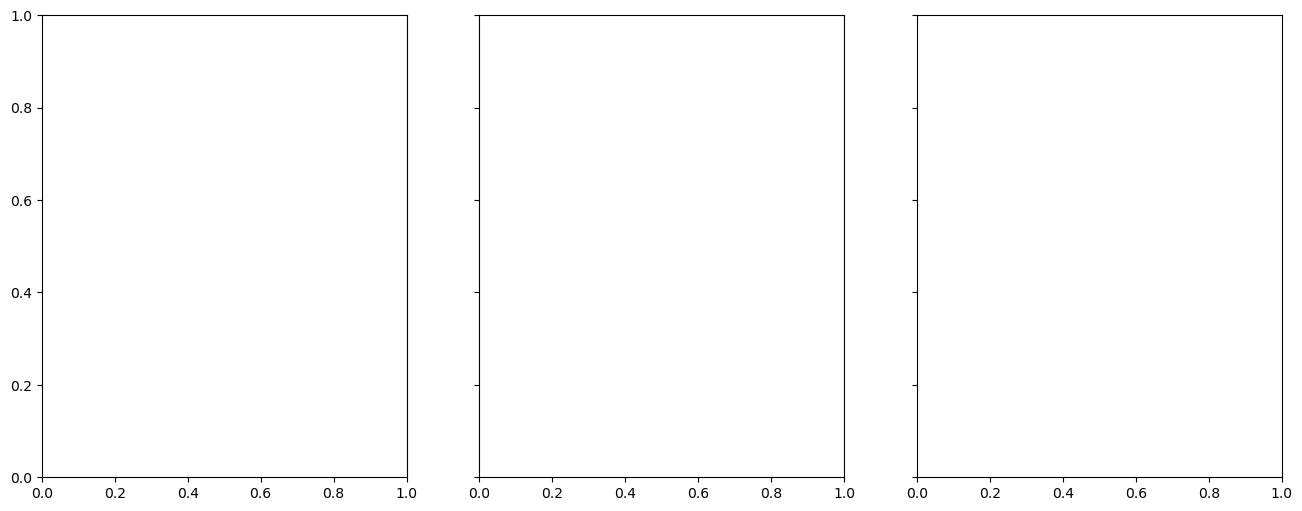

In [52]:
# Set up spatial comparison figure

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 6),
    sharex=True,
    sharey=True
)

# Consistent NDTI2 colour scale across all panels
vmin = -0.4
vmax = 0.4

In [53]:
# Plot selected high-flow events using a consistent NDTI2 scale

for ax, event_date, event_title in zip(
    axes,
    event_dates,
    event_titles
):

    # Match calendar date to Landsat observation
    idx = np.where(
        ds_dates == event_date.normalize()
    )[0]

    if len(idx) == 0:
        ax.set_title(f"{event_title}\nNo matching scene")
        ax.axis("off")
        continue

    # Extract event NDTI2
    event = ds.NDTI2.isel(
        time=idx[0]
    )

    # Plot NDTI2
    event.plot.imshow(
        ax=ax,
        cmap="BrBG_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.set_title(event_title)
    ax.set_xlabel("")
    ax.set_ylabel("")

In [54]:
# Add shared colour bar and finalise layout

mappable = plt.cm.ScalarMappable(
    cmap="BrBG_r",
    norm=plt.Normalize(
        vmin=vmin,
        vmax=vmax
    )
)

mappable.set_array([])

cbar = fig.colorbar(
    mappable,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.12
)

cbar.set_label("NDTI2")

fig.suptitle(
    "Spatial NDTI2 response during selected high-flow events",
    fontsize=14
)

plt.show()

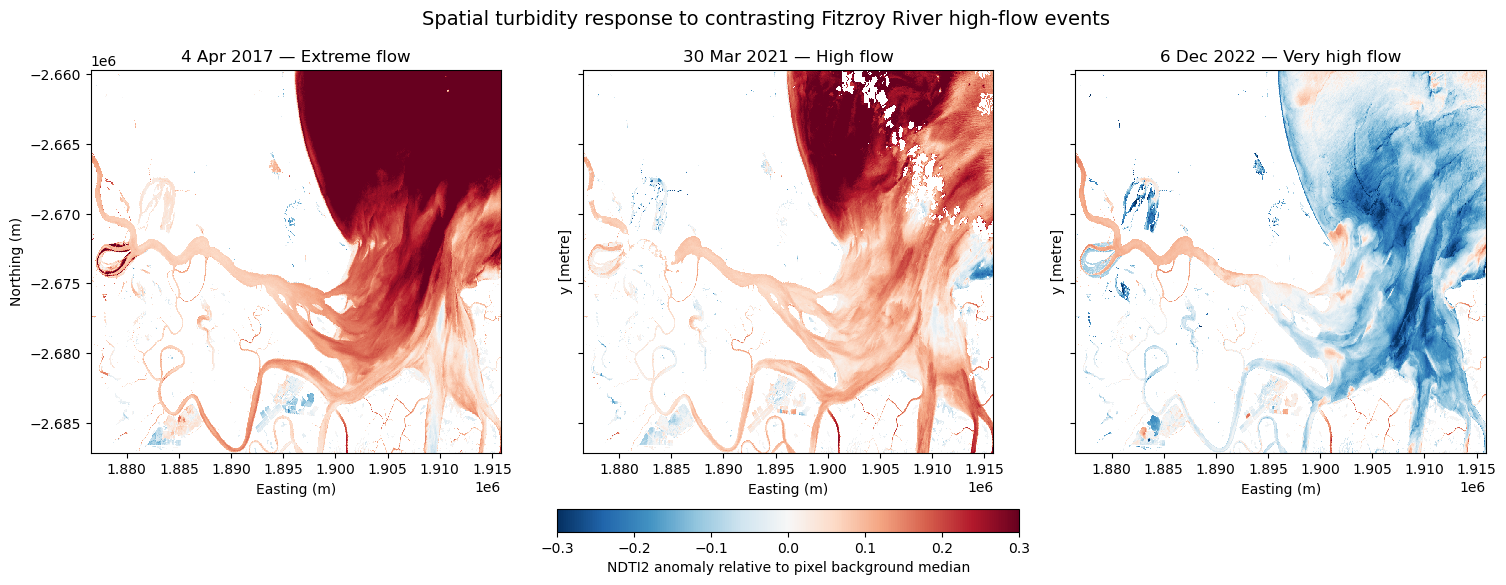

In [55]:
# Compare contrasting high-flow events spatially

event_dates = [
    pd.Timestamp("2017-04-04"),
    pd.Timestamp("2021-03-30"),
    pd.Timestamp("2022-12-06")
]

event_titles = [
    "4 Apr 2017 — Extreme flow",
    "30 Mar 2021 — High flow",
    "6 Dec 2022 — Very high flow"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    sharex=True,
    sharey=True
)

for ax, event_date, title in zip(
    axes, event_dates, event_titles
):

    # Find corresponding Landsat scene
    idx = np.where(ds_dates == event_date)[0]

    if len(idx) == 0:
        ax.set_title(f"{title}\nNo scene found")
        continue

    event = ds.NDTI2.isel(time=idx[0])

    # Difference from long-term pixel background
    anomaly = event - background_median

    anomaly.plot.imshow(
        ax=ax,
        cmap="RdBu_r",
        vmin=-0.3,
        vmax=0.3,
        add_colorbar=False
    )

    ax.set_title(title)
    ax.set_xlabel("Easting (m)")

axes[0].set_ylabel("Northing (m)")

# Shared colour bar
sm = plt.cm.ScalarMappable(
    cmap="RdBu_r",
    norm=plt.Normalize(vmin=-0.3, vmax=0.3)
)

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.12
)

cbar.set_label(
    "NDTI2 anomaly relative to pixel background median"
)

fig.suptitle(
    "Spatial turbidity response to contrasting Fitzroy River high-flow events",
    fontsize=14
)

plt.show()

## 12. Export selected event rasters for QGIS

The 21 February 2019 and 30 March 2021 observations were exported for final cartographic presentation in QGIS. For each event, the workflow exports the Landsat RGB composite, NDTI2 raster and binary elevated-NDTI2 mask used in the event comparison.

In [56]:
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray

# ------------------------------------------------------------
# FIGURE 4 EXPORTS
# Compare:
#   21 Feb 2019
#   30 Mar 2021
#
# Outputs for each event:
#   1. RGB Landsat GeoTIFF
#   2. Elevated-NDTI2 mask GeoTIFF
#   3. Event NDTI2 GeoTIFF (optional but useful)
# ------------------------------------------------------------

figure4_dates = {
    "2019_02_21": pd.Timestamp("2019-02-21"),
    "2021_03_30": pd.Timestamp("2021-03-30")
}

# CRS used in your analysis
output_crs = "EPSG:3577"

# ------------------------------------------------------------
# Helper function to locate a Landsat scene by calendar date
# ------------------------------------------------------------

def get_scene_index(target_date):

    target_date = pd.Timestamp(target_date).normalize()

    idx = np.where(
        pd.to_datetime(ds.time.values).normalize() == target_date
    )[0]

    if len(idx) == 0:
        raise ValueError(
            f"No Landsat observation found for {target_date.date()}"
        )

    return idx[0]


# ------------------------------------------------------------
# EXPORT EACH EVENT
# ------------------------------------------------------------

for label, target_date in figure4_dates.items():

    print("\n----------------------------------------")
    print(f"Processing {target_date.date()}")
    print("----------------------------------------")

    idx = get_scene_index(target_date)

    # Select Landsat scene
    scene = ds.isel(time=idx)

    # ========================================================
    # 1. TRUE-COLOUR RGB GEOTIFF
    # ========================================================

    # Stack red, green and blue as GeoTIFF bands 1, 2 and 3
    rgb_export = xr.concat(
        [
            scene["red"],
            scene["green"],
            scene["blue"]
        ],
        dim="band"
    )

    rgb_export = rgb_export.assign_coords(
        band=[1, 2, 3]
    )

    # Remove time coordinate if retained
    rgb_export = rgb_export.drop_vars(
        "time",
        errors="ignore"
    )

    # Ensure geospatial metadata is explicit
    rgb_export = rgb_export.rio.write_crs(
        output_crs
    )

    rgb_filename = (
        f"Figure4_{label}_RGB.tif"
    )

    rgb_export.rio.to_raster(
        rgb_filename,
        compress="DEFLATE"
    )

    print(f"Saved: {rgb_filename}")

    # ========================================================
    # 2. EVENT NDTI2
    # ========================================================

    event_ndti2 = scene["NDTI2"]

    event_ndti2 = event_ndti2.drop_vars(
        "time",
        errors="ignore"
    )

    event_ndti2 = event_ndti2.rio.write_crs(
        output_crs
    )

    ndti2_filename = (
        f"Figure4_{label}_NDTI2.tif"
    )

    event_ndti2.rio.to_raster(
        ndti2_filename,
        compress="DEFLATE"
    )

    print(f"Saved: {ndti2_filename}")

    # ========================================================
    # 3. ELEVATED-NDTI2 MASK
    #
    # 1   = event NDTI2 exceeds local background P90
    # 0   = valid analysed pixel but not elevated
    # 255 = NoData / outside valid comparison
    # ========================================================

    valid_comparison = (
        event_ndti2.notnull()
        & background_q90.notnull()
    )

    elevated = (
        event_ndti2 > background_q90
    )

    elevated_export = xr.where(
        ~valid_comparison,
        255,
        xr.where(
            elevated,
            1,
            0
        )
    ).astype("uint8")

    # Remove quantile coordinate inherited from background_q90
    elevated_export = elevated_export.drop_vars(
        "quantile",
        errors="ignore"
    )

    elevated_export = elevated_export.rio.write_crs(
        output_crs
    )

    elevated_export = elevated_export.rio.write_nodata(
        255
    )

    elevated_filename = (
        f"Figure4_{label}_Elevated_NDTI2.tif"
    )

    elevated_export.rio.to_raster(
        elevated_filename,
        compress="DEFLATE"
    )

    print(f"Saved: {elevated_filename}")

    # ========================================================
    # 4. CHECK ELEVATED AREA AGAINST EXISTING METHOD
    # ========================================================

    elevated_pixels = int(
        (elevated & valid_comparison)
        .sum()
        .compute()
        .values
    )

    elevated_area_km2 = (
        elevated_pixels * 0.0009
    )

    print(
        f"Elevated pixels: {elevated_pixels:,}"
    )

    print(
        f"Elevated area: {elevated_area_km2:.1f} km²"
    )

print("\nFigure 4 exports complete.")


----------------------------------------
Processing 2019-02-21
----------------------------------------
Saved: Figure4_2019_02_21_RGB.tif
Saved: Figure4_2019_02_21_NDTI2.tif
Saved: Figure4_2019_02_21_Elevated_NDTI2.tif
Elevated pixels: 158,785
Elevated area: 142.9 km²

----------------------------------------
Processing 2021-03-30
----------------------------------------
Saved: Figure4_2021_03_30_RGB.tif
Saved: Figure4_2021_03_30_NDTI2.tif
Saved: Figure4_2021_03_30_Elevated_NDTI2.tif
Elevated pixels: 275,323
Elevated area: 247.8 km²

Figure 4 exports complete.


## Tags
Browse all available tags on the DEA User Guide's [Tags Index](https://docs.dea.ga.gov.au/genindex.html)